In [2]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import seaborn as sns
from functools import partial
from scipy.optimize import minimize
import pandas as pd
import random
import matplotlib

# Ветвящиеся процессы

1. Оценить вероятность вырождения ВП по множеству симуляций и сравнить с точным ответом.

In [7]:
def sim_bp(num_gen, x_gen, z0 = 1):
    z = np.zeros(num_gen+1)
    z[0] = z0
    for i in range(1, num_gen+1):
        z_n = x_gen(n = z[i-1])        
        z[i] = z_n
    return z


In [14]:
def sim_bp_death(x_gen, max_gen = 1000, z0 = 1):
    gen = 0
    z_n = z0
    while z_n > 0 and gen < max_gen:
        gen += 1
        z_n = x_gen(n = z_n)
    if z_n == 0:
        return 0
    return 1


def check_law(p, num_sim, output = False):
    dead = 0
    for _ in range(num_sim):
        dead += 1 - sim_bp_death(partial(stats.nbinom.rvs, p = p))
    
    q = min(1, p/(1-p))
    if output:
        print(f"Empirical probability = {dead/num_sim}, theoretical = {q}")
    return dead/num_sim, q



In [15]:
def vary_p(p_vals = [0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 0.6, 0.7, 0.8], num_sim = 1000):
    emp, theory = [], []
    for p in p_vals:
        e, t = check_law(p, num_sim)
        emp.append(e)
        theory.append(t)
    plt.plot(p_vals, theory, marker='o', color = 'brown', label = 'Theoretical')
    plt.plot(p_vals, emp, marker ='o', color = 'hotpink', label = 'Empirical')
    plt.legend()
   



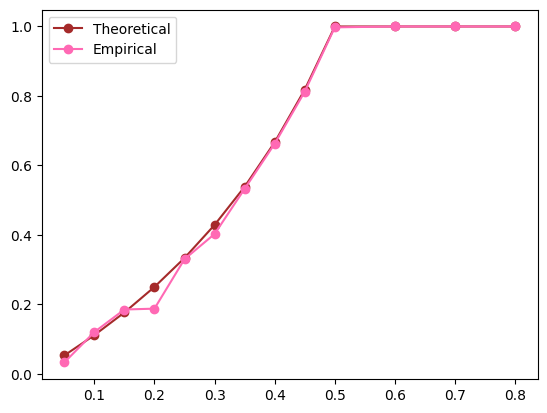

In [16]:
vary_p(num_sim = 400)

2. Смоделировать критический процесс 1000 раз до момента вырождения или до 50-го хода, отобрать
траектории, которые через 50 ходов еще живы, вывести их. Как их количество и численность
соответствующих процессов согласуется с предельной теоремой для ВП?

Сколько траекторий проживет 50 ходов в случае докритического процесса с геометрическ с p >
1/2? Моделировать процесс для различных p.

In [8]:
def sim_bp_death(x_gen, max_gen = 50, z0 = 1):
    gen = 0
    z = np.zeros(max_gen + 1)
    z[0] = z0
    z_n = z0
    while z_n > 0 and gen < max_gen:
        gen += 1
        z_n = x_gen(n = z_n)
        z[gen] = z_n
    if z_n == 0:
        return 0 , z
    return 1 , z


def sim_surv(p, num_sim = 1000, output = False):
    surv = 0 # number of suvived 
    amount = [] # mass of size of survived 
    sigma2 = (1-p)/p**2
    for _ in range(num_sim):
        res, z = sim_bp_death(partial(stats.nbinom.rvs, p = p))
        if res == 1:
            if output == True:
                plt.plot(z)
            surv += 1
            amount.append(z[-1]*50/(2*sigma2))
    if output:
        plt.title("Survived families trajectories")
        plt.show()
        plt.hist(amount, density = True, bins = 10)
        x = np.linspace(0,100,10000)
        plt.title("Survived families size")
        #plt.plot(x, stats.expon.pdf(x))
        plt.show()
    return surv

def count_num_surv(p, M = 100, num_sim = 100):
    mass = [] # proportion of survived families
    for _ in range(M):
        res = sim_surv(p, num_sim) # number of survived families
        mass.append(res/num_sim)
    plt.hist(mass, density = True, bins = 5)
    sigma2 = (1-p)/p**2
    plt.axvline(x = 2/(50*sigma2), color='red')
    print(f'Theoretical result = {2/(50*sigma2)}')
    plt.title("Количество выживших семей")
    plt.show()

        

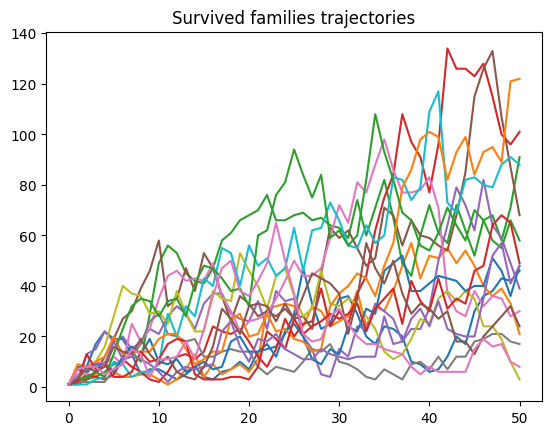

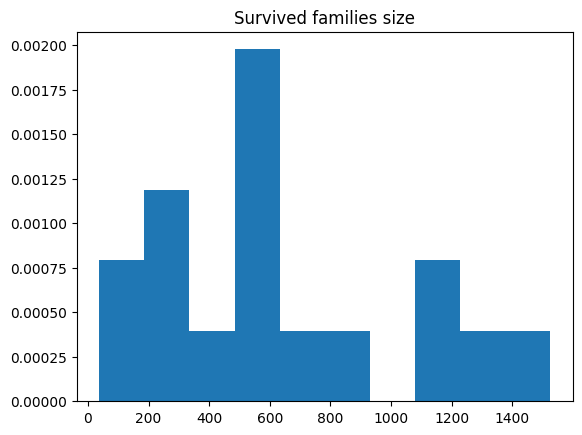

Theoretical result = 0.02


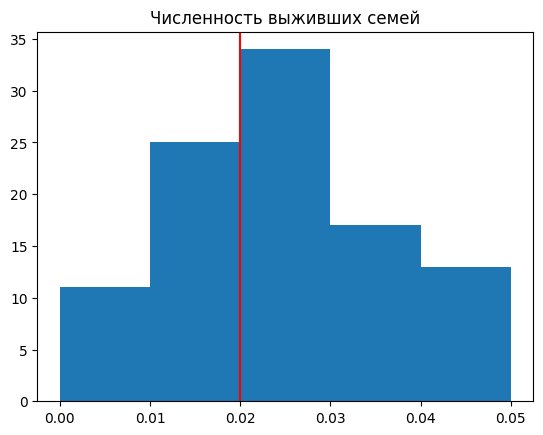

In [21]:
sim_surv(p = 1/2, output = True)
count_num_surv(1/2)

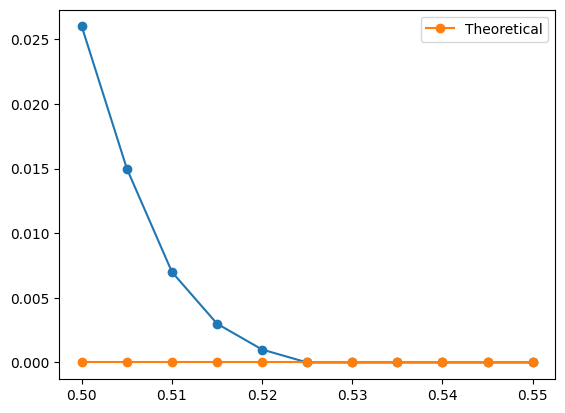

In [11]:
num_surv = []
num_simulations = 1000
max_gen = 50
p_vals = [0.5, 0.505, 0.51, 0.515, 0.52, 0.525, 0.53, 0.535, 0.54, 0.545, 0.55]
for p in p_vals:
    num_surv.append(sim_surv(p)/num_simulations)


theoretical = [i**max_gen*(2/((1-p)/p**2)) for i in p_vals]
plt.plot(p_vals, num_surv, marker='o')
plt.plot(p_vals, theoretical, marker='o', label = 'Theoretical')
plt.legend()
plt.show()


3. Смоделировать 20 шагов надкритического процесса с p = 0.45, построить график log Zn от n.
Построить несколько траекторий таких процессов.

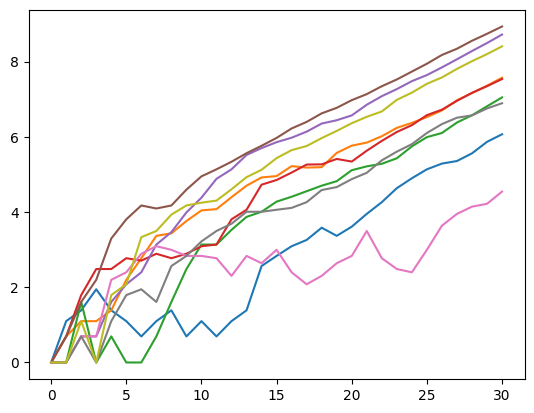

In [35]:
def sim_bp(num_gen, x_gen, z0 = 1):
    z = np.zeros(num_gen+1)
    z[0] = z0
    for i in range(1, num_gen+1):
        if z[i-1] == 0:
            break
        z[i] = x_gen(n = int(z[i-1]))         
    return z

for _ in range(50):
    z = sim_bp(30, partial(stats.nbinom.rvs, p=0.45))
    if z[-1] != 0:
        z = np.array(z)
        ln_z = np.log(z)
        plt.plot(ln_z)
    


4. Рассмотрим докритический ВП с иммиграцией в одну частицу. Найти численно вероятность того,
что в процессе k частиц в момент n, где k ≤ 5.

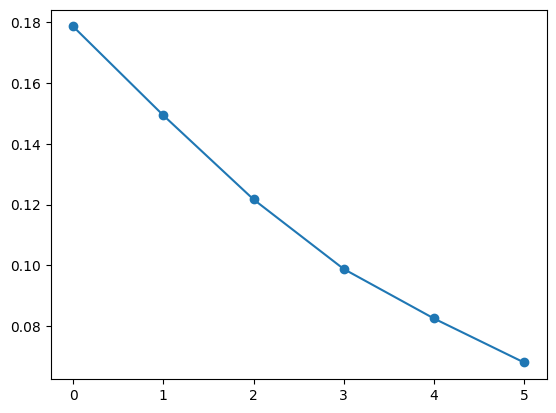

In [5]:
def sim_imm(num_gen, x_gen):
    z = np.zeros(num_gen+1)
    z[0] = 1
    for i in range(1, num_gen+1):
        z[i] = x_gen(n = int(z[i-1])+1)       
    return z


def empirical_prob(p, num_gen, x_gen = partial(stats.nbinom.rvs)):
    emp = np.zeros(6)
    z = np.zeros(num_gen+1)
    z[0] = 1
    for i in range(1, num_gen+1):
        z[i] = x_gen(p = 1-p, n = int(z[i-1])+1)
        #print(z[i])
        if z[i] in range(6):
            emp[int(z[i])] += 1       
    return emp/num_gen

res = empirical_prob(0.45, 100000)
plt.plot(res, marker='o')

5*. Рассмотрим а) надкритический, б) критический ВП. Моделировать процесс в течении 20 поколений
(дождавшись невырождения). Оценить с помощью ОМП среднее число потомков одной частицы и вероятность того, что частица дает ровно 0 потомков, а также вероятность того, что частица дает ровно одного потомка. Сравнить оценки с реальными значениями.

Задача также приносит 0.5 баллов по факультативу за 5 семинар.

In [42]:
def model_surv(p, num_gen = 20, num_sim = 10):
    # model processes til survival
    # num_gen = num generation we wait till
    # num_sim =  number of simulations (num of survived)

    # observations 
    num_children = 0 # number of children
    num_zeros = 0
    num_ones = 0
    survived = 0
    num_parents = 0

    while survived < num_sim:
        # simulating new process
        surv = 1
        num_child_temp = 0
        num_zeros_temp = 0
        num_ones_temp = 0

        z = np.zeros(num_gen, dtype = int)
        z[0] = 1
        for gen in range(1, num_gen):
            children = stats.geom.rvs(p, loc = -1, size = z[gen-1])
            zeros = np.count_nonzero(children == 0)
            ones = np.count_nonzero(children == 1)
            z[gen] = np.sum(children)
            #print(children)
            #print(zeros)
            #print(ones)
            #print()
            if z[gen] == 0:
                surv = 0
                break
            else:
                num_child_temp += np.sum(children)
                num_zeros_temp += zeros
                num_ones_temp += ones

        if surv:
            survived += 1
            num_children += num_child_temp
            num_zeros += num_zeros_temp
            num_ones += num_ones_temp
            num_parents += np.sum(z[:-1])

    print(f"Number of survived = {survived}")
    print(num_parents)
    emp_mean = num_children / num_parents
    emp_zero = num_zeros / num_parents
    emp_ones = num_ones / num_parents

    
    print(f"Mean = {(1-p)/p}, empirical = {emp_mean}")
    print(f'Probability of zero = {p}, empirical = {emp_zero}')
    print(f"Probability of one = {p*(1-p)}, empirical = {emp_ones}")




In [44]:
print("Supercritical case\n")
model_surv(2/5, num_sim = 3)

print("\nCritical case\n")
model_surv(1/2, num_sim = 3)

Supercritical case

Number of survived = 3
113321
Mean = 1.4999999999999998, empirical = 1.5122704529610576
Probability of zero = 0.4, empirical = 0.39771975185534897
Probability of one = 0.24, empirical = 0.23878186743851537

Critical case

Number of survived = 3
545
Mean = 1.0, empirical = 1.0954128440366973
Probability of zero = 0.5, empirical = 0.42935779816513764
Probability of one = 0.25, empirical = 0.28990825688073396
